References
https://www.kaggle.com/code/winternguyen/wind-power-curve-

Acknowledgement: 
The Preprocess pipeline Function and class CAREscore is co-authored by Kashif rizay and Nitesh morem


In [1]:
import seaborn as sns
from utils import *
from model import *
import pandas as pd
import matplotlib as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


 ### 🔍 Event and Feature Metadata: Overview & Usage

---


####  **Feature Metadata (sensor description)**

Sensor features are named as `sensor_x`, `power_x`, `reactive_power_x`, `wind_speed_x`. Each feature includes statistical types: `average`, `minimum`, `maximum`, and `std_dev`.

**Important columns**:
- `description`: Sensor meaning (e.g., rotor speed, yaw angle)  
- `unit`: Measurement unit (e.g., °C, bar, A)  
- `is_angle`: Marks angular measurements (e.g., yaw, pitch)  
- `is_counter`: Indicates cumulative counters (less useful for AD)

---

####  **Relevant Sensor Groups by Anomaly Type**

- **Hydraulic System** → `sensor_48–55`, `sensor_74`, `sensor_81–82`  
- **Pitch / Rotor Brake** → `sensor_12–14`, `sensor_54–55`, `sensor_76`, `sensor_100–105`, `sensor_9–11`  
- **Gear Oil / Mechanical** → `sensor_44–45`, `sensor_87–89`, `sensor_94`, `sensor_106`, `sensor_117–118`  
- **Electrical / Converter** → `sensor_35–38`, `power_5–6`, `power_17`, `sensor_127–131`, `reactive_power_119–122`  
- **Temperature / Environmental** → `sensor_7`, `sensor_15`, `sensor_18–21`, `sensor_62–65`, `sensor_74`  
- **Communication / Control** → `sensor_9–15`, `sensor_100–105`  
- **Yaw / Axis** → `sensor_27–34`, `sensor_62–64`, `sensor_100–105`

---

####  **Wind Speed Sensors**

- `wind_speed_235–237`: Used for power curve analysis  
- Help identify early deviations in turbine performance  


---

In [2]:
all_features = [
    'sensor_0_avg','sensor_0_std','sensor_1_std','sensor_3_std','sensor_8_std',
    'sensor_11_avg','sensor_11_std','sensor_12_avg','sensor_12_std','sensor_13_avg',
    'sensor_13_std','sensor_14_avg','sensor_14_std','sensor_15_std','sensor_16_avg',
    'sensor_22_avg','sensor_22_std','sensor_23_avg','sensor_23_std','sensor_24_avg',
    'sensor_24_std','sensor_25_avg','sensor_25_std','sensor_26_avg','sensor_26_std',
    'sensor_35_avg','sensor_35_std','sensor_37_avg','sensor_37_std','sensor_40_avg',
    'sensor_40_std','sensor_41_std','sensor_42_avg','sensor_42_std','sensor_43_avg',
    'sensor_43_std','sensor_44_std','sensor_45_avg','sensor_45_std','sensor_46_avg',
    'sensor_46_std','sensor_47_avg','sensor_47_std','sensor_48_avg','sensor_48_std',
    'sensor_53_avg','sensor_53_std','sensor_61_avg','sensor_61_std','sensor_65_std',
    'sensor_74_avg','sensor_74_std','sensor_75_avg','sensor_75_std','sensor_76_avg',
    'sensor_76_std','sensor_77_avg','sensor_78_avg','sensor_79_avg','sensor_80_avg',
    'sensor_81_std','sensor_82_avg','sensor_83_avg','sensor_83_std','sensor_84_std',
    'sensor_84_avg','sensor_85_std','sensor_85_avg','sensor_86_std','sensor_86_avg',
    'sensor_87_std','sensor_88_std','sensor_89_std','sensor_94_avg','sensor_94_std',
    'sensor_96_std','sensor_142_std','sensor_143_std','sensor_170_avg','sensor_170_std',
    'sensor_171_avg','sensor_171_std','sensor_172_avg','sensor_172_std','sensor_175_std',
    'sensor_176_avg','sensor_176_std','sensor_177_avg','sensor_177_std','sensor_188_avg',
    'sensor_205_avg','sensor_210_avg','sensor_210_std','sensor_213_avg','sensor_213_std',
    'sensor_214_avg','sensor_214_std','sensor_215_avg','sensor_215_std','sensor_217_avg',
    'sensor_217_std','sensor_218_avg','sensor_225_avg','sensor_226_avg','sensor_226_std',
    'sensor_230_avg','sensor_230_std','sensor_27_merged_avg','sensor_36_merged_avg',
    'sensor_36_merged_std','sensor_49_merged_avg','sensor_49_merged_std','sensor_51_merged_avg',
    'sensor_54_merged_avg','sensor_54_merged_std','sensor_56_merged_std','sensor_56_merged_avg',
    'sensor_58_merged_avg','sensor_58_merged_std','sensor_62_merged_std','sensor_66_merged_avg',
    'sensor_66_merged_std','sensor_69_merged_avg','sensor_69_merged_std','sensor_71_merged_avg',
    'sensor_71_merged_std','sensor_97_merged_avg','sensor_100_merged_avg','sensor_100_merged_std',
    'sensor_107_merged_avg','sensor_107_merged_std','sensor_109_merged_avg','sensor_109_merged_std',
    'sensor_111_merged_std','sensor_113_merged_std','sensor_115_merged_std','sensor_117_merged_avg',
    'sensor_117_merged_std','sensor_123_merged_std','sensor_127_merged_avg','sensor_127_merged_std',
    'sensor_136_merged_avg','sensor_136_merged_std','sensor_139_merged_std','sensor_139_merged_avg',
    'sensor_144_merged_avg','sensor_144_merged_std','sensor_151_merged_avg','sensor_151_merged_std',
    'sensor_168_merged_avg','sensor_168_merged_std','sensor_173_merged_avg','sensor_182_merged_std',
    'sensor_186_merged_avg','sensor_189_merged_avg','sensor_191_merged_avg','sensor_194_merged_std',
    'sensor_196_merged_avg','sensor_199_merged_avg','sensor_208_merged_std','sensor_216_merged_avg',
    'sensor_216_merged_std','sensor_219_merged_avg','sensor_219_merged_std','sensor_220_merged_avg',
    'sensor_220_merged_std','sensor_228_merged_avg','sensor_228_merged_std','sensor_231_merged_avg',
    'sensor_231_merged_std','sensor_233_merged_avg',
    'sensor_1_avg','sensor_7_std','sensor_9_avg','sensor_9_std','sensor_10_avg','sensor_10_std',
    'sensor_16_std','sensor_39_std','sensor_77_std','sensor_78_std','sensor_79_std','sensor_80_std',
    'sensor_81_avg','sensor_90_merged_std','sensor_92_merged_std','sensor_95_avg','sensor_95_std',
    'sensor_96_avg','sensor_97_merged_std','sensor_167_std','sensor_178_merged_std','sensor_188_std',
    'sensor_191_merged_std','sensor_193_std','sensor_196_merged_std','sensor_205_std',
    'sensor_206_merged_std','sensor_218_std','sensor_225_std','sensor_227_std'
]

>Basically, the idea is to use data samples which have status id 0 in the train(train_test feature) segment of the dataset. 

>We choose this approach as we realised during the data analysis and preprocessing that. all the other status ids are flagged faults already known by the operators. 

>And the developing anomalies are usually in he normal data as we are doing predictive maintenance. 

>So this a key factor to look for anomaly samples in normal data points or basically deviationin in the normal points. With this approach it can be easy to generalise across different turbines.


# Supervised Approach

In [3]:
df_anomaly= pd.read_csv(r"44.csv", delimiter=";")

In [4]:
# --- Filter train & test ---
df_train_anomaly = df_anomaly[(df_anomaly['train_test'] == 'train') & (df_anomaly['status_type_id'] == 0)].copy()
df_test_anomaly = df_anomaly[(df_anomaly['train_test'] == 'prediction')].copy()

Silhouette Score not valid.


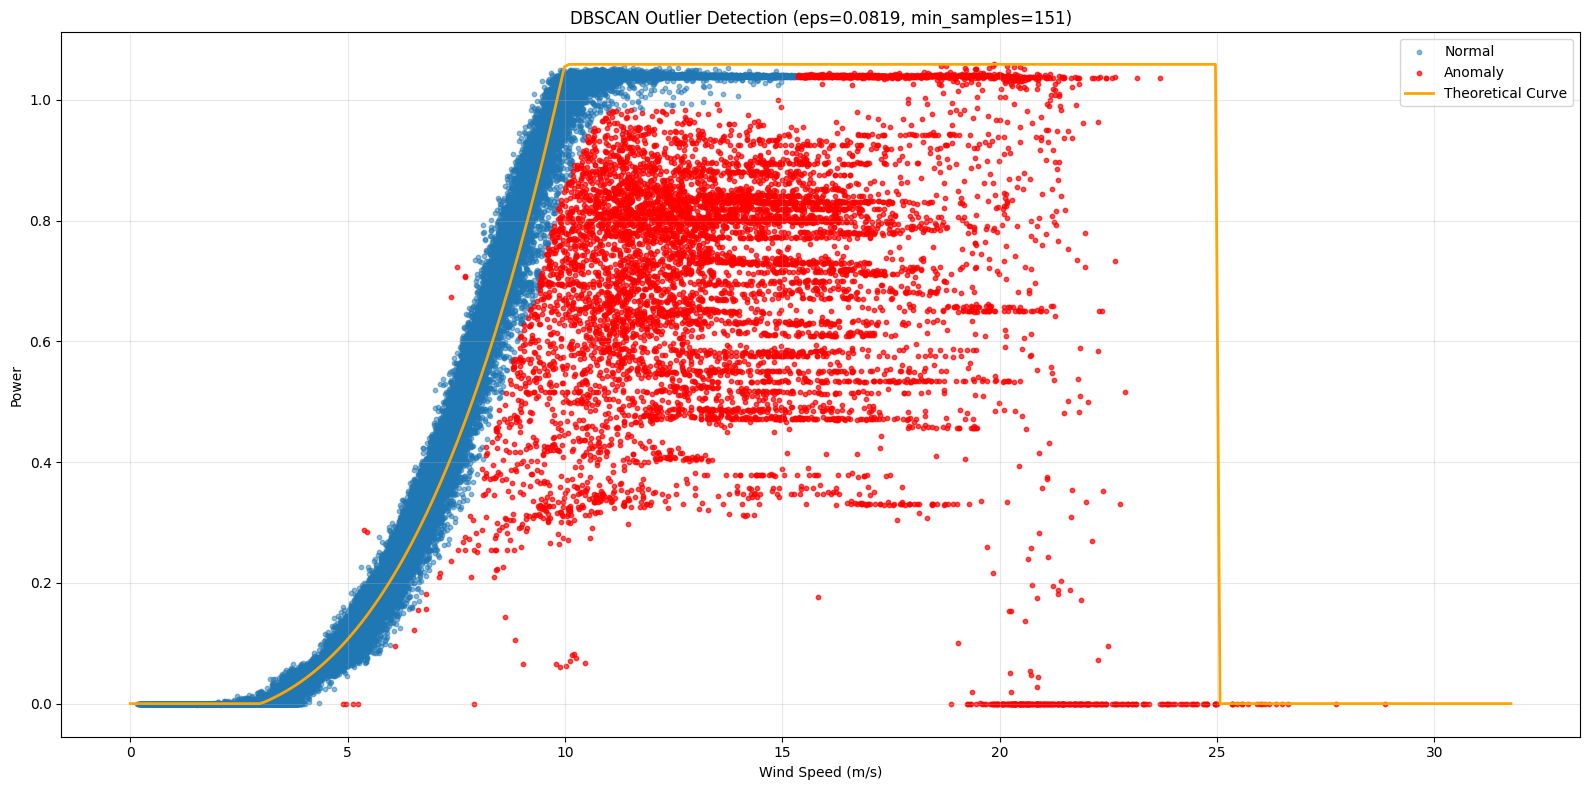

Ignore the silhoutte score as I am using clustering here just for sepration.


In [5]:
# --- DBSCAN Outlier Detection  ---
df_train_anomaly = dbscan_outlier_detection_new(df_train_anomaly, eps=0.0819, min_samples=151, plot=True)
df_train_anomaly['dbscan_label'] = (df_train_anomaly['label'] == 'anomaly').astype(float)
print("Ignore the silhoutte score as I am using clustering here just for sepration.")

# KDE Gaussian -- Basically all the overlapping  Anamoly points are removed by checking the density of overlapping normal points as seen in the graphs

> In the Original DBscan anamoly plot there is high density of overlapping points at 1.0 which are also in normal and Anamoly

> These points are removed with all the points more tha 0.99 are removed and we get a cleaned anomalies

> Further filtering was not done as anomaly points are less and normal points are more , so i think it is better to have less important data rather than no data at all 

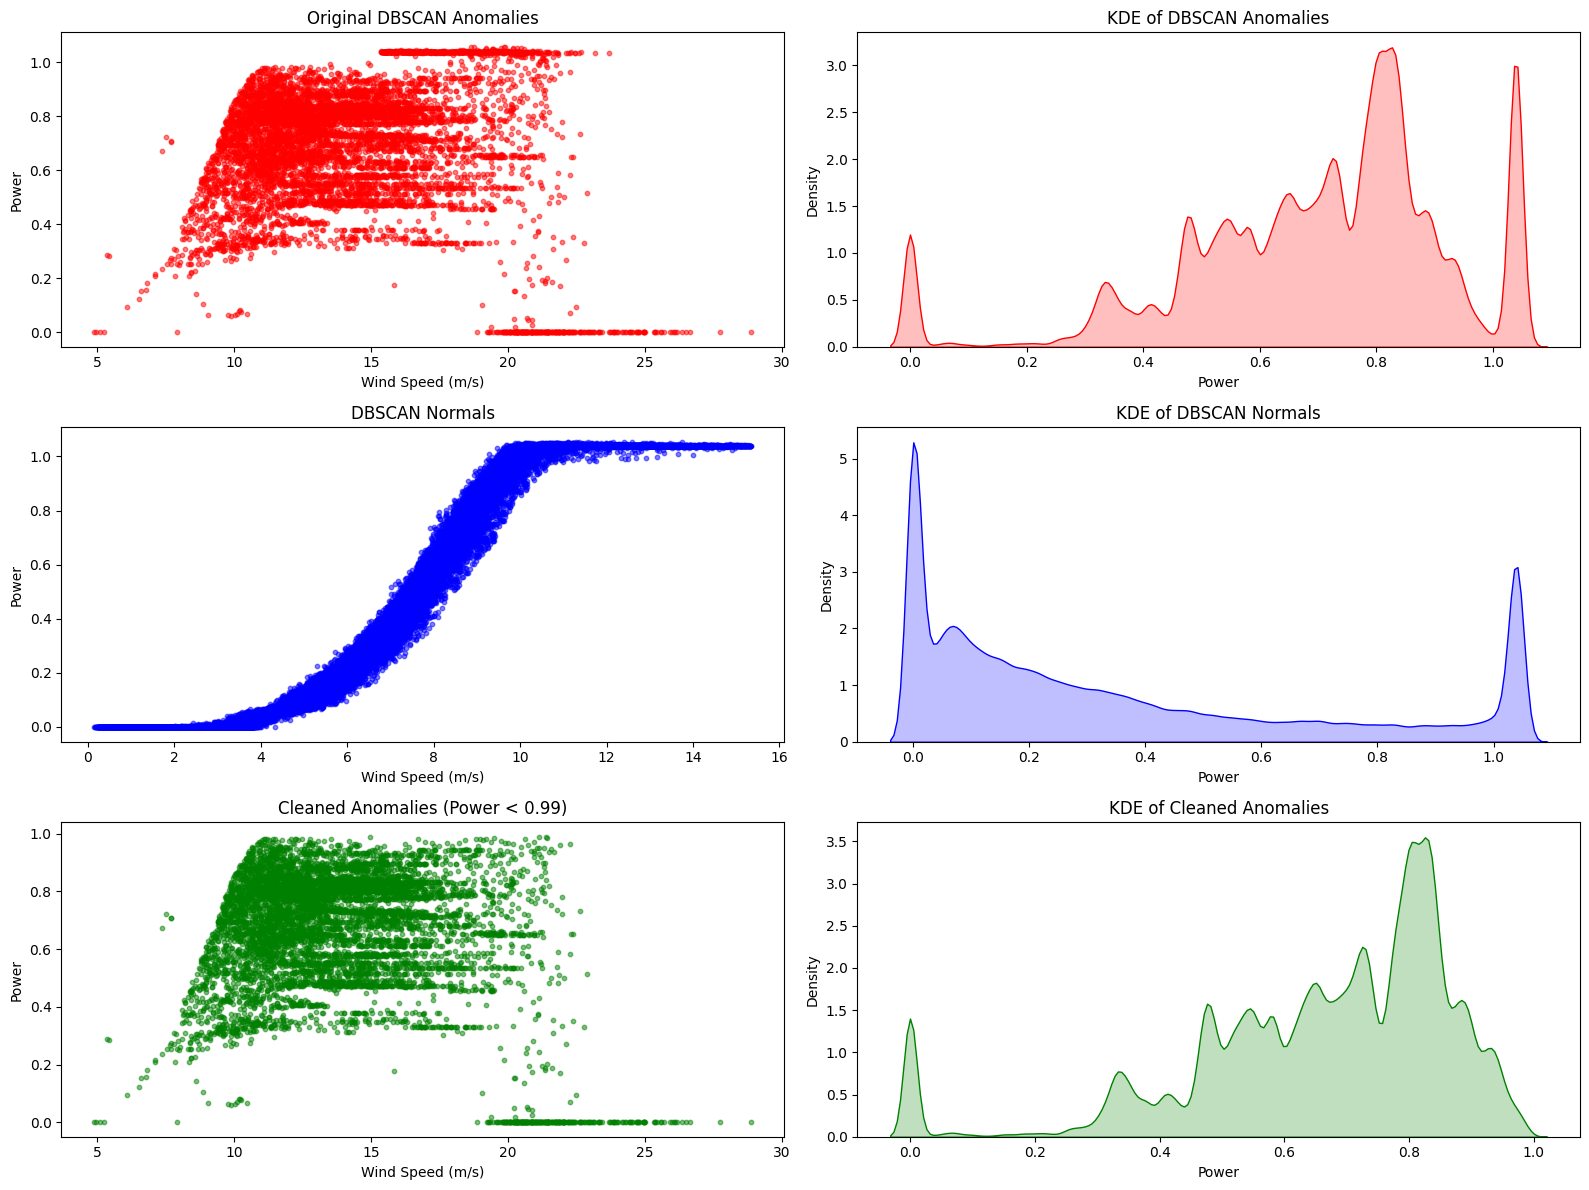

,time_stamp,asset_id,id,train_test,status_type_id,sensor_0_avg,sensor_0_max,sensor_0_min,sensor_0_std,sensor_1_avg,...,wind_speed_235_min,wind_speed_235_std,wind_speed_237_avg,wind_speed_237_max,wind_speed_237_min,wind_speed_237_std,cluster,label,dbscan_label,kde_density
495,2022-08-06 00:30:00,44,495,train,0,36.474,43.2,26.3,4.368,-0.0067,...,4.0,1.0360,8.435,11.6,4.5,0.9415,-1,anomaly,1.0,0.649578
500,2022-08-06 01:20:00,44,500,train,0,20.189,23.4,15.9,1.792,-0.0134,...,4.6,0.8477,7.376,9.6,4.0,0.7407,-1,anomaly,1.0,1.156071
1668,2022-08-14 04:00:00,44,1668,train,0,72.666,96.2,15.3,28.127,0.0934,...,2.8,2.5550,10.625,17.2,2.1,2.7000,-1,anomaly,1.0,0.312983
2377,2022-08-19 02:10:00,44,2377,train,0,76.691,93.3,33.1,16.010,-0.0530,...,3.8,5.1800,13.436,26.9,4.3,5.3700,-1,anomaly,1.0,0.363684
2391,2022-08-19 04:30:00,44,2391,train,0,59.395,90.0,25.0,20.473,0.0418,...,2.6,2.5370,9.973,16.8,2.3,2.6490,-1,anomaly,1.0,0.349837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52133,2023-07-30 14:50:00,44,52133,train,0,40.082,49.4,33.5,4.387,0.0264,...,4.1,1.5280,9.016,13.8,3.0,1.7040,-1,anomaly,1.0,0.566346
52134,2023-07-30 15:00:00,44,52134,train,0,44.902,54.3,36.7,4.709,0.0004,...,4.2,1.6280,9.280,14.3,3.1,1.7670,-1,anomaly,1.0,0.477140
52135,2023-07-30 15:10:00,44,52135,train,0,49.277,62.1,39.0,5.241,-0.0133,...,3.8,1.6380,9.756,14.8,4.6,1.8490,-1,anomaly,1.0,0.419130
52138,2023-07-30 15:40:00,44,52138,train,0,55.976,68.6,45.2,5.939,0.0192,...,3.9,1.5990,9.486,14.2,4.1,1.7320,-1,anomaly,1.0,0.365668


In [6]:
 
plot_anomalies_and_kde(df_train_anomaly, 
                       wind_col='wind_speed_235_avg', 
                       power_col='power_2_avg', 
                        )


In [7]:
# ---  Getting refined anomaly points (power < 0.99)
refined_anomalies = df_train_anomaly[
    (df_train_anomaly['label'] == 'anomaly') &
    (df_train_anomaly['power_2_avg'] < 0.99)
]

# ---  Creating the final labels for the full training data
df_train_anomaly['final_label'] = 0  # default all to normal
# Setting only refined anomalies to 1
df_train_anomaly.loc[refined_anomalies.index, 'final_label'] = 1

# Ensure integer type
df_train_anomaly['final_label'] = df_train_anomaly['final_label'].astype(int)


In [8]:
# --- Debug or visualize ---
print(df_train_anomaly['final_label'].value_counts())

final_label
0    41698
1     7254
Name: count, dtype: int64


## Train test split 

> The Preprocesspipeline function is used to drop min and max columns and also it takes list of merge sensors and drop sensors which was finalised in utils.py file. The function is automated for simplicity purpose and ore interpretability.
the result is 240 feature with avg and std features

> Xtest -  After pre-processing train segment of dataset, the feature
space  with only the sensors and removing
the metadata, i have 240 features. And also all the values were scaled
using standard scaler.

In [9]:
#----------Making X_train---------------- 
X_train = preprocess_pipeline(df_train_anomaly)
X_train=X_train.drop(columns=['cluster','dbscan_label', 'time_stamp','asset_id','id','train_test','status_type_id','label','final_label'])
X_train= X_train.select_dtypes(exclude=['object', 'string'])


In [10]:
X_train

,sensor_0_avg,sensor_0_std,sensor_1_std,sensor_3_avg,sensor_3_std,sensor_4_avg,sensor_4_std,sensor_7_avg,sensor_8_avg,sensor_8_std,...,sensor_228_merged_avg,sensor_228_merged_std,sensor_231_merged_avg,sensor_231_merged_std,sensor_233_merged_avg,sensor_233_merged_std,power_2_merged_avg,power_2_merged_std,wind_speed_235_merged_avg,wind_speed_235_merged_std
0,-0.431457,-0.339545,-0.276638,-1.222665,2.364974,2.927714,2.578365,1.760816,0.061182,-0.108244,...,0.399516,-0.855125,-1.753002,2.822734,0.703725,-0.663627,-0.431927,-0.312276,-0.266072,-0.462570
1,-0.459353,-0.452993,-0.543257,-0.863579,3.066355,2.208043,2.405806,1.763349,0.032817,-0.248026,...,0.218930,-0.914205,-1.740386,2.822012,0.783237,-0.537809,-0.459790,-0.425134,-0.311879,-0.483405
2,-0.530396,-0.196558,-0.401170,-1.080364,2.682760,2.059187,2.361187,1.777986,-0.046713,0.219549,...,0.368927,-0.426946,-1.722728,2.813058,0.872123,-0.249372,-0.530173,-0.159211,-0.343171,-0.205129
3,-0.561095,-0.471814,-0.614026,-1.222920,2.364309,2.054752,2.357852,1.788964,-0.079747,-0.207900,...,0.515867,-0.516228,-1.504093,3.901763,1.062816,-0.356258,-0.561725,-0.444741,-0.416756,-0.569374
4,-0.527561,-0.364116,-0.425857,-1.224140,2.361923,2.051404,2.356971,1.788964,-0.040789,-0.074522,...,0.917509,1.276383,0.791614,-0.317983,0.900665,2.125841,-0.527564,-0.336788,-0.309750,-0.484738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52452,-0.345847,-0.361764,-0.221778,-1.215035,2.379346,0.653145,1.613053,1.790372,0.152741,-0.199611,...,0.701747,0.864831,0.098696,-0.325132,0.633583,1.124488,-0.347399,-0.333182,-0.288809,-0.414534
52453,-0.174432,0.017268,-0.076948,-0.880456,3.037944,2.227499,2.396744,1.772920,0.306776,0.120458,...,0.752687,0.215126,0.104589,-0.333037,0.654029,0.234091,-0.176491,0.034627,-0.224035,-0.332277
52454,-0.079730,0.449364,0.192963,-1.496857,1.496573,3.455455,2.647968,1.778831,0.381998,0.546399,...,0.335635,-0.716626,0.101221,-0.329069,0.276478,-0.474678,-0.081973,0.464437,-0.185365,-0.303006
52455,-0.374362,-0.232632,0.012474,-0.779396,3.201637,-0.399893,-0.405614,1.741393,0.124915,-0.015557,...,0.720334,1.247042,0.102060,-0.314767,0.565995,2.094522,-0.376137,-0.200867,-0.306849,-0.394811


> X-test = The prediction frame was used for testing the model and
was also preprocessed with same dimensions as X-train without any
metadata.

In [11]:
#---------Making X_test-------------------
X_test = preprocess_pipeline(df_test_anomaly )
X_test=X_test.drop(columns=[  'time_stamp','asset_id','id','train_test','status_type_id'])
X_test= X_test.select_dtypes(exclude=['object', 'string'])

In [12]:
 
df_train_anomaly['final_label'] = df_train_anomaly['final_label'].astype(int)
df_train_anomaly['final_label'].value_counts()

final_label
0    41698
2     7254
Name: count, dtype: int64

In [13]:
#----------Making y_train-----------------(Labels)
df_train_anomaly['final_label'] = (df_train_anomaly['final_label'] > 0).astype(int)

y_train = df_train_anomaly['final_label']


In [14]:
#--------Checking  labels--------
#--------There is a clear huge class imbalance problem
y_train.value_counts()

final_label
0    41698
1     7254
Name: count, dtype: int64

---------Making y_true or Ground Truth provided by event_info.csv------------

In [15]:
y_true = np.zeros(len(df_test_anomaly), dtype=int)
anomaly_mask = (df_test_anomaly['id'] >= 52704) & (df_test_anomaly['id'] <= 62138)
y_true[anomaly_mask.values] = 1

# Models

Why RandforestClassifier

>It handles noisy, high-dimensional SCADA data well.

>It's robust to feature scale (but we scaled anyway).

>It's interpretable (you can get feature importance).

>It’s quick to train and works well even with moderate data.

About hyperparameters 
- n_estimators = this help with more trees and helps reduce variance (in my case more 180 was better)
- max_depth = Restricts tree growth to avoid overfitting to noise as we already have a very noisy data seen in the power curve.(helps in avoiding overfitting)
- min_samples_leaf = helps in generalizing,  like each leaf has enough samples.
- max_features = Prevents over-reliance on a few dominant features as it can be biased towards few features.

Max_features and min_samples_leaf --these regularization parameters force the model to split only when enough supporting evidence exists, which helps generalize early anomaly trends.



In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(n_estimators=180, max_depth=12,random_state=42,min_samples_split=22,min_samples_leaf = 11,max_features = 'sqrt' )
rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=12, min_samples_leaf=11, min_samples_split=22,
                       n_estimators=180, random_state=42)

,feature,mean_abs_shap
0,wind_speed_235_merged_avg,0.044002
1,sensor_100_merged_avg,0.043804
2,sensor_26_avg,0.016006
3,sensor_76_std,0.012960
4,sensor_76_avg,0.010367
5,sensor_133_merged_std,0.010035
6,sensor_133_merged_avg,0.009450
7,reactive_power_120_avg,0.009141
8,wind_speed_235_merged_std,0.009038
9,reactive_power_121_std,0.008352


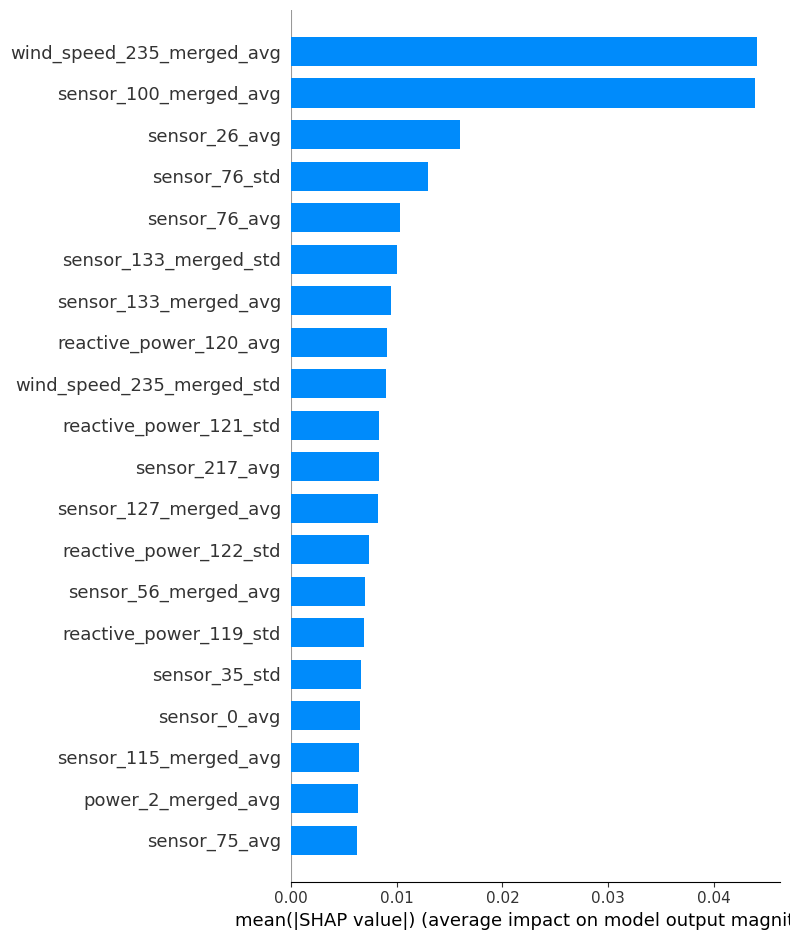

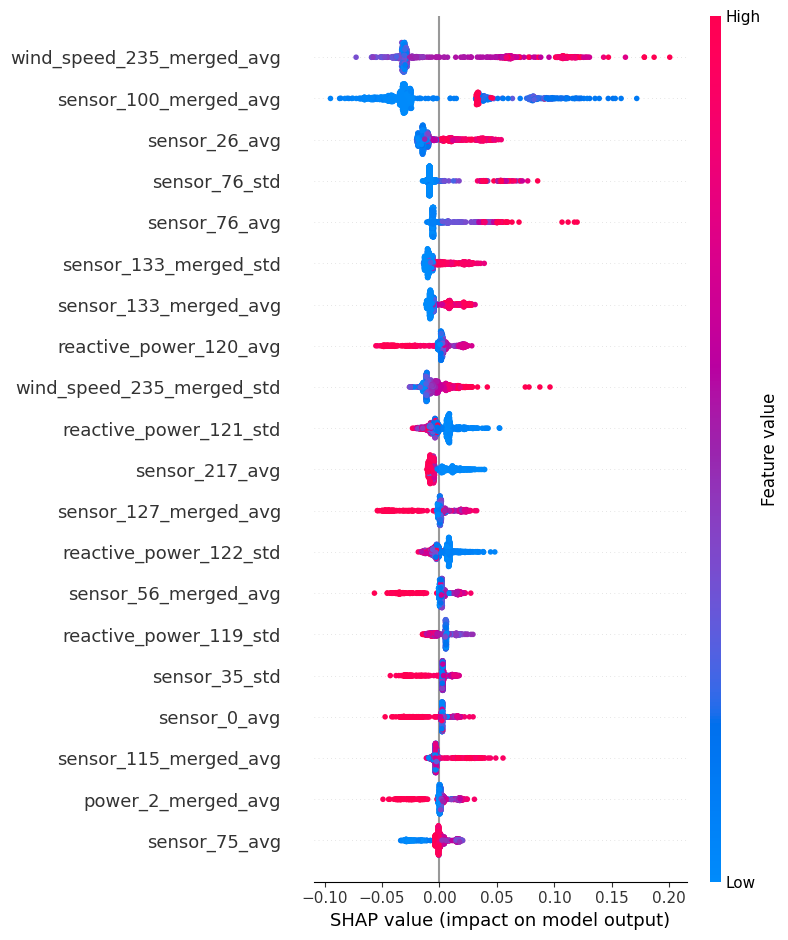

Explaining sampled row index: 22286
Predicted anomaly probability: 1.000


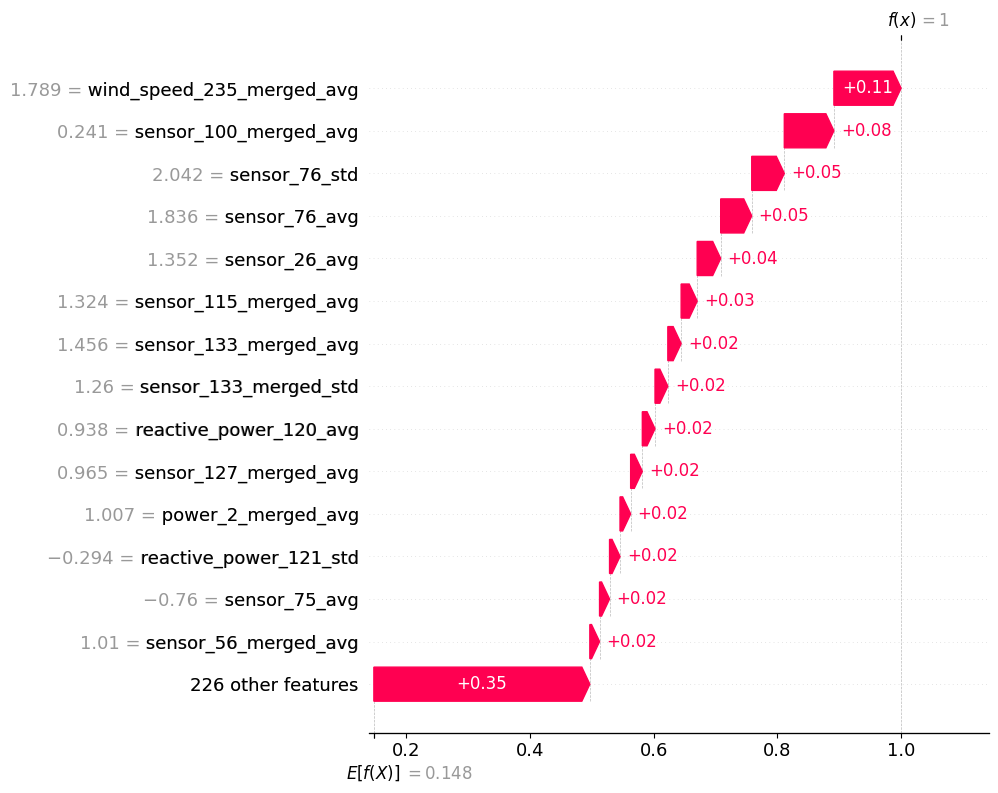

In [ ]:


# SHAP explains how each feature pushes the Random Forest prediction toward
# normal (class 0) or anomaly (class 1). For traceability, 
# anomaly class because that is the class we care about detecting.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import shap
except ImportError as exc:
    raise ImportError("Install SHAP first with: pip install shap") from exc

shap.initjs()

# Use a fixed sample so SHAP is fast and reproducible in the notebook.
# If you want full-data explanations later, increase shap_sample_size.
shap_sample_size = min(1000, len(X_train))
X_shap = X_train.sample(n=shap_sample_size, random_state=42)

explainer = shap.TreeExplainer(rf)
raw_shap_values = explainer.shap_values(X_shap)

# SHAP has slightly different return shapes across versions.
# This block consistently selects class 1: the anomaly class.
if isinstance(raw_shap_values, list):
    shap_values_anomaly = raw_shap_values[1]
    expected_value_anomaly = explainer.expected_value[1]
elif np.asarray(raw_shap_values).ndim == 3:
    shap_values_anomaly = raw_shap_values[:, :, 1]
    expected_value_anomaly = explainer.expected_value[1]
else:
    shap_values_anomaly = raw_shap_values
    expected_value_anomaly = explainer.expected_value

# Global traceability table: mean absolute SHAP value ranks the strongest
# drivers of anomaly predictions across the sampled training rows.
shap_feature_importance = (
    pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values_anomaly).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(shap_feature_importance.head(20))

# Global explanation 1: compact feature ranking.
shap.summary_plot(
    shap_values_anomaly,
    X_shap,
    plot_type="bar",
    max_display=20,
    show=True,
)

# Global explanation 2: direction of influence.
# Red points mean high feature values, blue points mean low feature values.
# Points to the right increase anomaly probability; points to the left reduce it.
shap.summary_plot(
    shap_values_anomaly,
    X_shap,
    max_display=20,
    show=True,
)

# Local traceability: explain the sampled row with the highest anomaly probability.
anomaly_probabilities = rf.predict_proba(X_shap)[:, 1]
local_idx = int(np.argmax(anomaly_probabilities))

local_explanation = shap.Explanation(
    values=shap_values_anomaly[local_idx],
    base_values=expected_value_anomaly,
    data=X_shap.iloc[local_idx],
    feature_names=X_shap.columns,
)

print(f"Explaining sampled row index: {X_shap.index[local_idx]}")
print(f"Predicted anomaly probability: {anomaly_probabilities[local_idx]:.3f}")
shap.plots.waterfall(local_explanation, max_display=15)


### SHAP Interpretation and Model Traceability

The labels and many sensor names in this dataset are anonymised, so the SHAP analysis should not be treated as a final physical root-cause explanation. We do not have fully descriptive true fault labels such as gearbox fault, blade issue, generator issue, or hydraulic issue. Because of that, the goal here is more modest: to check whether the Random Forest is using sensible operational signals and to make its anomaly predictions more traceable.

The SHAP bar plot shows the global feature influence. It ranks features by mean absolute SHAP value, which means it shows which features had the largest average impact on the model output. In this model, features such as `wind_speed_235_merged_avg`, `sensor_100_merged_avg`, `sensor_26_avg`, `sensor_76_std`, `reactive_power_120_avg`, and power-related signals appear near the top. This is a useful sign because wind speed, power, reactive power, and sensor variation are operationally plausible signals for wind turbine anomaly detection.

The SHAP beeswarm plot adds direction. Points on the right side increase the anomaly prediction, and points on the left side reduce it. Red points are high feature values and blue points are low feature values. For example, if high values of a wind speed or power-related feature are mostly on the right side, the model has learned that those high values are associated with anomaly-like behaviour. If low values are on the right side, the model has learned the opposite pattern for that feature.

The waterfall plot explains one individual prediction. It starts from the model baseline output and then shows which features pushed that specific sample toward the anomaly class. This helps move from a black-box output such as `anomaly = 1` to a traceable explanation such as: this sample was flagged mainly because wind speed, sensor averages, sensor variation, power, or reactive power features pushed the prediction upward.

Overall, the SHAP results suggest that the model is not relying only on arbitrary hidden patterns. It is giving high importance to signals that humans would also expect to be relevant in a wind farm setting, especially wind and power-related measurements. However, because the labels and feature descriptions are anonymised, this should be presented as an interpretability and traceability check rather than a confirmed engineering diagnosis. SHAP helps us understand what the model is using, verify that the important features are reasonable, and explain individual anomaly predictions in a more transparent way.


SAving the model

In [34]:
# import pickle

# # Save the model
# with open("my_random_forest.pkl", "wb") as f:
#     pickle.dump(rf, f)

# # Later, to load the model:
# with open("my_random_forest.pkl", "rb") as f:
#     rf = pickle.load(f)


In [35]:
rf

RandomForestClassifier(max_depth=12, min_samples_leaf=11, min_samples_split=22,
                       n_estimators=180, random_state=42)

In [36]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')
print("Cross-validated F1 scores:", scores)


Cross-validated F1 scores: [0.96285714 0.98888117 0.96941176 0.98037866 0.9789916 ]


In [37]:
threshold = 0.6

y_score = rf.predict_proba(X_test)[:, 1]
y_pred = (y_score > threshold).astype(int)

In [38]:
from model import CAREScore
care = CAREScore(beta=0.5)

tp = ((y_true == 1) & (y_pred == 1)).sum()
fp = ((y_true == 0) & (y_pred == 1)).sum()
fn = ((y_true == 1) & (y_pred == 0)).sum()
tn = ((y_true == 0) & (y_pred == 0)).sum()

coverage_fbeta = care.f_beta(tp, fp, fn)
print("📍 Coverage Fβ:", coverage_fbeta)


accuracy_score = care.accuracy(tn, fp)
print("✅ Accuracy (Normal):", accuracy_score)

📍 Coverage Fβ: 0.22170411191182704
✅ Accuracy (Normal): 0.933531746031746


In [39]:
event_list = []
start_id, end_id = 52704, 62138

# Get the index positions (not the id values)
mask = (df_test_anomaly['id'] >= start_id) & (df_test_anomaly['id'] <= end_id)
indices = np.where(mask)[0]

if len(indices) > 0:
    event_list.append((indices[0], indices[-1]))


In [40]:
tp_events = 0
fn_events = 0

for start, end in event_list:
    if y_pred[start:end+1].sum() > 0:
        tp_events += 1
    else:
        fn_events += 1


def find_events(y):
    events = []
    in_event = False
    for i, val in enumerate(y):
        if val == 1 and not in_event:
            start = i
            in_event = True
        elif val == 0 and in_event:
            end = i - 1
            events.append((start, end))
            in_event = False
    if in_event:
        events.append((start, len(y) - 1))
    return events

pred_events = find_events(y_pred)


fp_events = 0
for p_start, p_end in pred_events:
    if not any((p_start <= e_end and p_end >= e_start) for e_start, e_end in event_list):
        fp_events += 1

reliability_fbeta = care.event_f_beta(tp_events, fp_events, fn_events)
print("📦 Reliability Fβ:", reliability_fbeta)



📦 Reliability Fβ: 0.07692307692307693


In [41]:
earliness_scores = []

for start, end in event_list:
    if y_pred[start:end+1].sum() > 0:
        score = care.weighted_earliness(y_pred.tolist(), start, end)
        earliness_scores.append(score)


earliness = np.mean(earliness_scores) if earliness_scores else 0.0
print("⏱️ Earliness Score:", earliness)


⏱️ Earliness Score: 0.045036822973635676


In [42]:
care_score = care.compute_care(
    coverage_fbeta,
    accuracy_score,
    reliability_fbeta,
    earliness
)
print("🎯 Final CARE Score:", care_score)


🎯 Final CARE Score: 0.26444651616278425


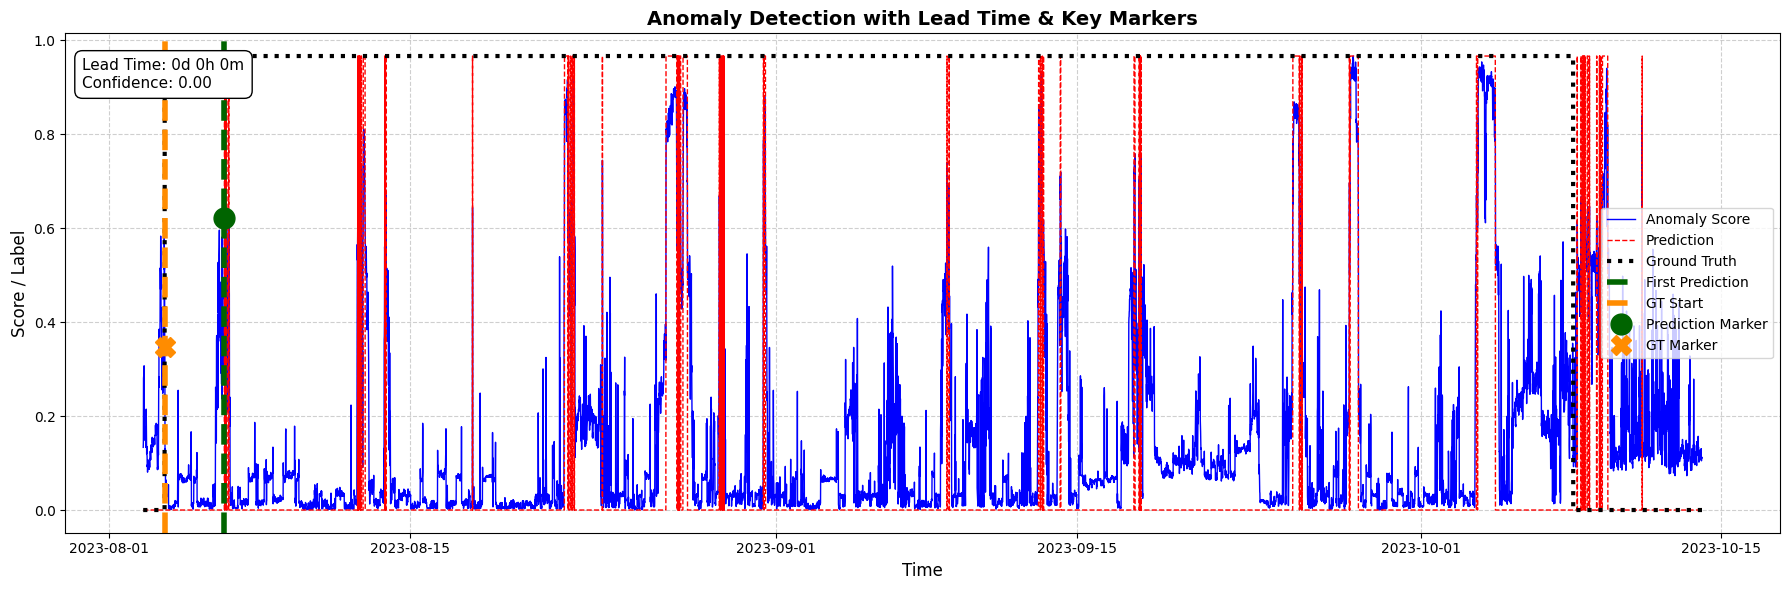

{'gt_start': '2023-08-03 14:00:00', 'pred_start': '2023-08-06 08:40:00', 'lead_time_steps': 0, 'lead_time_minutes': 0, 'lead_time_readable': '0d 0h 0m', 'peak_confidence': 0.0}


In [43]:
result = plot_prediction_with_leadtime_and_annotation(
    y_score,
    y_pred,
    y_true,
    df_test_anomaly['time_stamp'],  # or your timestamp column
    
)


# Testing with Other Datasets...



| event_id | event_start_id | event_end_id |
|----------|---------------|--------------|
| 55       | 52848         | 55320        |
| 81       | 52704         | 53067        |
| 47       | 52416         | 53128        |
| 12       | 52560         | 55818        |
| 4        | 52992         | 55728        |
| 18       | 51408         | 51983        |
| 28       | 52704         | 55629        |
| 39       | 52848         | 53582        |
| 66       | 51696         | 52638        |
| 15       | 51984         | 54432        |
| 78       | 52560         | 52857        |
| 79       | 52704         | 52992        |
| 30       | 52560         | 55822        |
| 33       | 52848         | 55728        |
| 11       | 52416         | 55572        |
| 44       | 52704         | 62138        |
| 49       | 51840         | 52437        |
| 31       | 52848         | 53868        |
| 67       | 52704         | 61056        |
| 9        | 52992         | 56028        |
| 91       | 52704         | 55599        |
| 5        | 52272         | 52794        |
| 90       | 52848         | 54591        |
| 70       | 52560         | 55461        |
| 35       | 51696         | 52614        |
| 16       | 51264         | 53423        |
| 76       | 51552         | 51797        |


In [44]:
from typing import Tuple, List
 

def evaluate_care_score(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
    df_test: pd.DataFrame,
    start_id: int,
    end_id: int,
    care_model=None
) -> Tuple[float, float, float, float, float]:
    """
    Evaluate CARE Score and its components from predictions and ground truth.

    Parameters:
        y_true: Ground truth binary labels (0 = normal, 1 = anomaly)
        y_pred: Binary predictions (0/1)
        y_score: Model's soft anomaly scores or probabilities
        df_test: Test dataframe containing 'id' and 'timestamp'
        start_id: ID indicating start of known fault window
        end_id: ID indicating end of known fault window
        care_model: CAREScore object (optional, if already initialized)

    Returns:
        Tuple of (coverage, accuracy, reliability, earliness, final_care)
    """
    from model import CAREScore
    care = care_model or CAREScore(beta=0.5)

    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()

    coverage_fbeta = care.f_beta(tp, fp, fn)
    accuracy_score = care.accuracy(tn, fp)

    # Define event_list based on id range
    event_list = []
    mask = (df_test['id'] >= start_id) & (df_test['id'] <= end_id)
    indices = np.where(mask)[0]
    if len(indices) > 0:
        event_list.append((indices[0], indices[-1]))

    # Event detection
    tp_events = sum([y_pred[start:end+1].sum() > 0 for start, end in event_list])
    fn_events = len(event_list) - tp_events

    def find_events(y):
        events = []
        in_event = False
        for i, val in enumerate(y):
            if val == 1 and not in_event:
                start = i
                in_event = True
            elif val == 0 and in_event:
                end = i - 1
                events.append((start, end))
                in_event = False
        if in_event:
            events.append((start, len(y) - 1))
        return events

    pred_events = find_events(y_pred)
    fp_events = sum(
        not any(p_start <= e_end and p_end >= e_start for e_start, e_end in event_list)
        for p_start, p_end in pred_events
    )

    reliability_fbeta = care.event_f_beta(tp_events, fp_events, fn_events)

    # Earliness calculation
    earliness_scores = []
    for start, end in event_list:
        if y_pred[start:end+1].sum() > 0:
            weights = np.linspace(1, 0, end - start + 1)
            e_score = sum([p * w for p, w in zip(y_pred[start:end+1], weights)]) / sum(weights)
            earliness_scores.append(e_score)

    earliness = np.mean(earliness_scores) if earliness_scores else 0.0
    final_care = care.compute_care(coverage_fbeta, accuracy_score, reliability_fbeta, earliness)

    # Print summary
    print(f"📍 Coverage Fβ: {coverage_fbeta:.4f}")
    print(f"✅ Accuracy (Normal): {accuracy_score:.4f}")
    print(f"📦 Reliability Fβ: {reliability_fbeta:.4f}")
    print(f"⏱️ Earliness Score: {earliness:.4f}")
    print(f"🎯 Final CARE Score: {final_care:.4f}")

    return coverage_fbeta, accuracy_score, reliability_fbeta, earliness, final_care


In [ ]:
 
 
def run_prediction_pipeline(
    df,
    preprocess_pipeline,
    rf,
    threshold=0.6,
    event_start_id=51840,
    event_end_id=52437,
    plot_function=plot_prediction_with_leadtime_and_annotation,
    evaluate_function=evaluate_care_score
):
    
    """
    Run the complete prediction pipeline for anomaly detection using a trained classifier.

    Parameters:
    - df (pd.DataFrame): Input dataframe with labeled and prediction regions.
    - preprocess_pipeline (function): Preprocessing pipeline to apply on test data.
    - rf (model): Trained classifier (e.g., RandomForestClassifier).
    - threshold (float): Probability threshold to convert scores into binary predictions.
    - event_start_id (int): ID indicating the start of known anomaly event.
    - event_end_id (int): ID indicating the end of the anomaly event.
    - plot_function (function): Function used to visualize predictions and lead time.
    - evaluate_function (function): Function used to compute CARE evaluation metrics.

    Returns:
    - dict: Dictionary containing predictions, scores, ground truth, plots, and evaluation.
    """
    
    # Step 1: Filter prediction data
    df_test_new = df[df['train_test'] == 'prediction'].copy()
    
    # Step 2: Preprocess
    X_test_new = preprocess_pipeline(df_test_new)
    
    # Step 3: Drop unnecessary columns
    drop_cols = ['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id']
    X_test_new = X_test_new.drop(columns=drop_cols, errors='ignore')
    
    # Step 4: Predict probabilities and binary outcomes
    y_score_new = rf.predict_proba(X_test_new)[:, 1]
    y_pred_new = (y_score_new > threshold).astype(int)
    
    # Step 5: Create ground truth
    y_true_new = np.zeros(len(df_test_new), dtype=int)
    mask = (df_test_new['id'] >= event_start_id) & (df_test_new['id'] <= event_end_id)
    y_true_new[mask.values] = 1
    
    # Step 6: Get event list
    event_indices = np.where(mask)[0]
    event_list_new = [(event_indices[0], event_indices[-1])] if len(event_indices) > 0 else []

    # Step 7: Plot prediction
    plot_result = plot_function(
        y_score_new,
        y_pred_new,
        y_true_new,
        df_test_new['time_stamp']
    )

    # Step 8: Evaluate CARE score
    care_score = evaluate_function(
        y_true=y_true_new,
        y_pred=y_pred_new,
        y_score=y_score_new,
        df_test=df_test_new,
        start_id=event_start_id,
        end_id=event_end_id
    )

    return {
        'y_score': y_score_new,
        'y_pred': y_pred_new,
        'y_true': y_true_new,
        'df_test': df_test_new,
        'event_list': event_list_new,
        'plot': plot_result,
        'care_score': care_score
    }


In [ ]:
df_55 = pd.read_csv('55.csv', delimiter=';')  #Done 0.6
df_81 = pd.read_csv('81.csv', delimiter=';')  #Done 0.5
df_47 = pd.read_csv('47.csv', delimiter=';')  #Done 0.5  Not eng pt
df_12 = pd.read_csv('12.csv', delimiter=';')  #DOne 0.5  Not eng pt
df_4  = pd.read_csv('4.csv',  delimiter=';')  #Done 0.6
df_18 = pd.read_csv('18.csv', delimiter=';')  #Done 0.6  Not eng pt
df_28 = pd.read_csv('28.csv', delimiter=';')  #Done 0.45 Developing anomalies or weak
df_39 = pd.read_csv('39.csv', delimiter=';')  #Done 0.6  Very weak anomalies before failure
df_66 = pd.read_csv('66.csv', delimiter=';')  #Done 0.6  Not eng pt and weak anomalies
df_15 = pd.read_csv('15.csv', delimiter=';')  #Done 0.6
df_78 = pd.read_csv('78.csv', delimiter=';')  #done 0.6  Not eng pt
df_79 = pd.read_csv('79.csv', delimiter=';')  #Done 0.6  very weak and not eng pt 
df_30 = pd.read_csv('30.csv', delimiter=';')  #Done 0.6  Not eng points and weak  
df_33 = pd.read_csv('33.csv', delimiter=';')  #Done 0.5  Developing anomalies
df_11 = pd.read_csv('11.csv', delimiter=';')  #Done 0.5  Not eng pts
df_44 = pd.read_csv('44.csv', delimiter=';')  #DONE 0.6
df_49 = pd.read_csv('49.csv', delimiter=';')  #DONE 0.6
df_31 = pd.read_csv('31.csv', delimiter=';')  #Done 0.45
df_67 = pd.read_csv('67.csv', delimiter=';')  #Done 0.60
df_9  = pd.read_csv('9.csv',  delimiter=';')  #Done 0.40
df_91 = pd.read_csv('91.csv', delimiter=';')  #Done 0.6
df_5  = pd.read_csv('5.csv',  delimiter=';')  #Done 0.5
df_90 = pd.read_csv('90.csv', delimiter=';')  #Done 0.6 weak anomalies
df_70 = pd.read_csv('70.csv', delimiter=';')  #Done 0.6 Not eng pts
df_35 = pd.read_csv('35.csv', delimiter=';')  #Done 0.5
df_16 = pd.read_csv('16.csv', delimiter=';')  #Done 0.6  Very Weak Anomaly
df_76 = pd.read_csv('76.csv', delimiter=';')  #Done 0.6

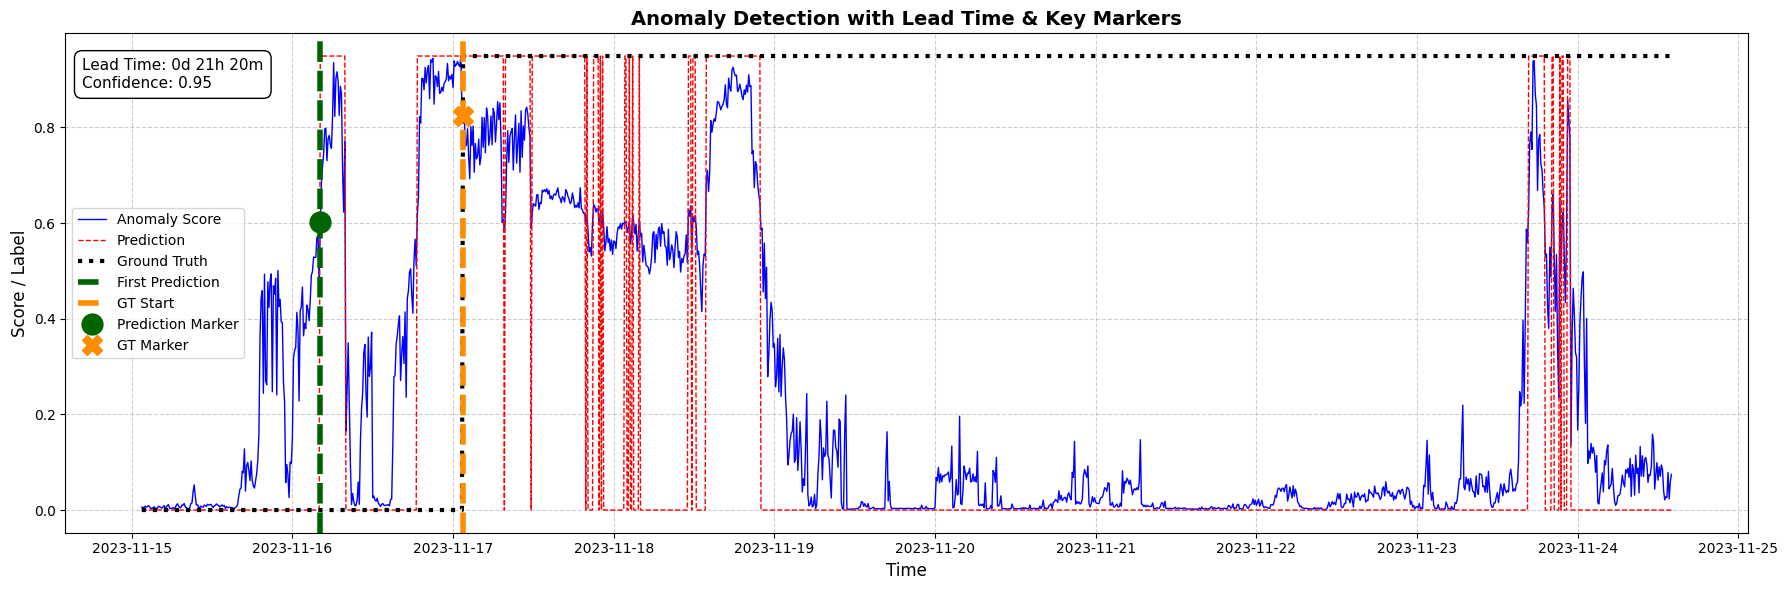

{'gt_start': '2023-11-17 01:30:00', 'pred_start': '2023-11-16 04:10:00', 'lead_time_steps': 128, 'lead_time_minutes': 1280, 'lead_time_readable': '0d 21h 20m', 'peak_confidence': 0.9491155715893579}
📍 Coverage Fβ: 0.4658
✅ Accuracy (Normal): 0.7778
📦 Reliability Fβ: 0.5556
⏱️ Earliness Score: 0.2939
🎯 Final CARE Score: 0.4774


In [47]:
df_new = df_81

results = run_prediction_pipeline(
    df_new,
    preprocess_pipeline,
    rf,
    threshold=0.6,
    event_start_id=52848,
    event_end_id=55320
)

## Plots for all the datasets below

In [ ]:
results_55 = run_prediction_pipeline(df_55, preprocess_pipeline, rf, threshold=0.6, event_start_id=52848, event_end_id=55320)

In [ ]:
results_47 = run_prediction_pipeline(df_47, preprocess_pipeline, rf, threshold=0.5, event_start_id=52416, event_end_id=53128)

In [ ]:
 
results_12 = run_prediction_pipeline(df_12, preprocess_pipeline, rf, threshold=0.5, event_start_id=52560, event_end_id=55818)

In [ ]:
results_4  = run_prediction_pipeline(df_4,  preprocess_pipeline, rf, threshold=0.6, event_start_id=52992, event_end_id=55728)

In [ ]:
results_18 = run_prediction_pipeline(df_18, preprocess_pipeline, rf, threshold=0.6, event_start_id=51408, event_end_id=51983)

In [ ]:
results_28 = run_prediction_pipeline(df_28, preprocess_pipeline, rf, threshold=0.45, event_start_id=52704, event_end_id=55629)

In [ ]:
results_39 = run_prediction_pipeline(df_39, preprocess_pipeline, rf, threshold=0.6, event_start_id=52848, event_end_id=53582)

In [ ]:
results_66 = run_prediction_pipeline(df_66, preprocess_pipeline, rf, threshold=0.6, event_start_id=51696, event_end_id=52638)


In [ ]:
results_15 = run_prediction_pipeline(df_15, preprocess_pipeline, rf, threshold=0.6, event_start_id=51984, event_end_id=54432)


In [ ]:
results_78 = run_prediction_pipeline(df_78, preprocess_pipeline, rf, threshold=0.6, event_start_id=52560, event_end_id=52857)


In [ ]:
results_30 = run_prediction_pipeline(df_30, preprocess_pipeline, rf, threshold=0.6, event_start_id=52560, event_end_id=55822)


In [ ]:
results_33 = run_prediction_pipeline(df_33, preprocess_pipeline, rf, threshold=0.5, event_start_id=52848, event_end_id=55728)


In [ ]:
results_11 = run_prediction_pipeline(df_11, preprocess_pipeline, rf, threshold=0.5, event_start_id=52416, event_end_id=55572)


In [ ]:
results_44 = run_prediction_pipeline(df_44, preprocess_pipeline, rf, threshold=0.6, event_start_id=52704, event_end_id=62138)

In [ ]:
results_49 = run_prediction_pipeline(df_49, preprocess_pipeline, rf, threshold=0.6, event_start_id=51840, event_end_id=52437)


In [ ]:
results_49 = run_prediction_pipeline(df_49, preprocess_pipeline, rf, threshold=0.6, event_start_id=51840, event_end_id=52437)


In [ ]:
results_31 = run_prediction_pipeline(df_31, preprocess_pipeline, rf, threshold=0.45, event_start_id=52848, event_end_id=53868)


In [ ]:
results_67 = run_prediction_pipeline(df_67, preprocess_pipeline, rf, threshold=0.6, event_start_id=52704, event_end_id=61056)

In [ ]:
results_9  = run_prediction_pipeline(df_9,  preprocess_pipeline, rf, threshold=0.4, event_start_id=52992, event_end_id=56028)


In [ ]:
results_91 = run_prediction_pipeline(df_91, preprocess_pipeline, rf, threshold=0.6, event_start_id=52704, event_end_id=55599)


In [ ]:
results_5  = run_prediction_pipeline(df_5,  preprocess_pipeline, rf, threshold=0.5, event_start_id=52272, event_end_id=52794)


In [ ]:
results_90 = run_prediction_pipeline(df_90, preprocess_pipeline, rf, threshold=0.6, event_start_id=52848, event_end_id=54591)


In [ ]:
results_70 = run_prediction_pipeline(df_70, preprocess_pipeline, rf, threshold=0.6, event_start_id=52560, event_end_id=55461)


In [ ]:
results_35 = run_prediction_pipeline(df_35, preprocess_pipeline, rf, threshold=0.5, event_start_id=51696, event_end_id=52614)


In [ ]:
results_16 = run_prediction_pipeline(df_16, preprocess_pipeline, rf, threshold=0.6, event_start_id=51264, event_end_id=53423)


In [ ]:
results_76 = run_prediction_pipeline(df_76, preprocess_pipeline, rf, threshold=0.6, event_start_id=51552, event_end_id=51797)
